# 07. Main policy analysis and numerical diagnostics

This notebook summarizes the model-implied comparison of the myopic, displacement-naive forward-looking, and displacement-aware policies. It loads the frozen empirical-Bayes policy artifact from Notebook 06 and exports compact numerical diagnostics used by the final reporting notebook.

The paper-facing decomposition and figures are created in Notebook 08 after the reporting denominators and robustness outputs are available.

All reported values are conditional on the calibrated demand-displacement model, the supported action sets, and the assumed funding environment. They should not be interpreted as causal estimates of the profit effect of implementing the recommended calendars.

## 1. Load the selected policy artifact

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Suppress pandas transition warnings so the notebook output remains focused on
# substantive diagnostics.
warnings.filterwarnings("ignore", category=FutureWarning)

# Locate the repository root from either the project root or notebooks folder.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        root
        for root in [CURRENT_DIR, *CURRENT_DIR.parents]
        if (root / "pyproject.toml").is_file()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root. "
        "Run the notebook from the repository or notebooks directory."
    )

# Make the local package importable without requiring an editable installation.
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dynamic_promotion_planning.policy import (
    load_pickle,
    save_pickle,
)
from dynamic_promotion_planning.boundaries import (
    build_policy_switch_table,
)

# Canonical artifact and reporting directories.
EB_VERSION = "empirical_bayes_price_consistent"
POLICY_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "policy" / EB_VERSION
TABLE_DIR = PROJECT_ROOT / "results" / EB_VERSION / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / EB_VERSION / "figures"

for directory in [
    POLICY_ARTIFACT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

In [2]:
# Load the complete policy-optimization artifact created by Notebook 06.
POLICY_ARTIFACT_PATH = POLICY_ARTIFACT_DIR / "policy_optimization.pkl"

if not POLICY_ARTIFACT_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {POLICY_ARTIFACT_PATH}. Run Notebook 06 first."
    )

artifact = load_pickle(POLICY_ARTIFACT_PATH)

# Recover the policy grid, washout diagnostics, and additive decompositions.
policy_results = (
    artifact["policy_results"]
    .copy()
    .sort_values(["capacity", "alpha"])
    .reset_index(drop=True)
)
washout_results = artifact["washout_results"].copy()
washout_stability = artifact["washout_stability"].copy()
product_decomposition = artifact["product_decomposition"].copy()
weekly_decomposition = artifact["weekly_decomposition"].copy()

if policy_results.empty:
    raise RuntimeError("The policy-results artifact contains no grid rows.")

if washout_results.empty or washout_stability.empty:
    raise RuntimeError("The terminal-washout diagnostics are empty.")

if product_decomposition.empty or weekly_decomposition.empty:
    raise RuntimeError("At least one policy decomposition is empty.")

# Recover schedules and calibrated inputs needed for boundary analysis.
schedules = artifact["schedules"]
draws_by_product = artifact["draws_by_product"]
weekly_profiles = artifact["weekly_profiles"]
action_sets = artifact["action_sets"]
support_table = artifact["support_table"]
products = list(artifact["products"])
planning = artifact["schedule_system"]["planning"]

SELECTED_WASHOUT = int(artifact["selected_washout"])
CAPACITIES = list(artifact["capacities"])
ECONOMIC_PROFILE_MODE = str(artifact["economic_profile_mode"])

# Confirm that the demand-only economic specification was preserved.
if not all(
    np.allclose(np.asarray(values["price_factor"], dtype=float), 1.0)
    for values in weekly_profiles.values()
):
    raise AssertionError(
        "Price factors are not fixed to one in the final artifact."
    )

if not all(
    np.allclose(np.asarray(values["cost_factor"], dtype=float), 1.0)
    for values in weekly_profiles.values()
):
    raise AssertionError(
        "Cost factors are not fixed to one in the final artifact."
    )

print("Selected washout:", SELECTED_WASHOUT)
print("Policy rows:", len(policy_results))

Selected washout: 36
Policy rows: 404


## 2. Terminal-tail diagnostic

This retained numerical diagnostic records the fixed terminal-tail evaluation used by the policy artifact. It is not presented as a graphical sensitivity analysis when only one configured horizon is available.

In [3]:
# Display the washout-selection diagnostics and mark the selected horizon.
washout_stability_display = washout_stability.copy()
washout_stability_display["selected"] = (
    washout_stability_display["washout_horizon"].eq(SELECTED_WASHOUT)
)

display(washout_stability_display)

,washout_horizon,maximum_absolute_vdo_change,maximum_terminal_state,vdo_stable,terminal_state_small,selected
0,36,NaN,0.008578,False,True,True


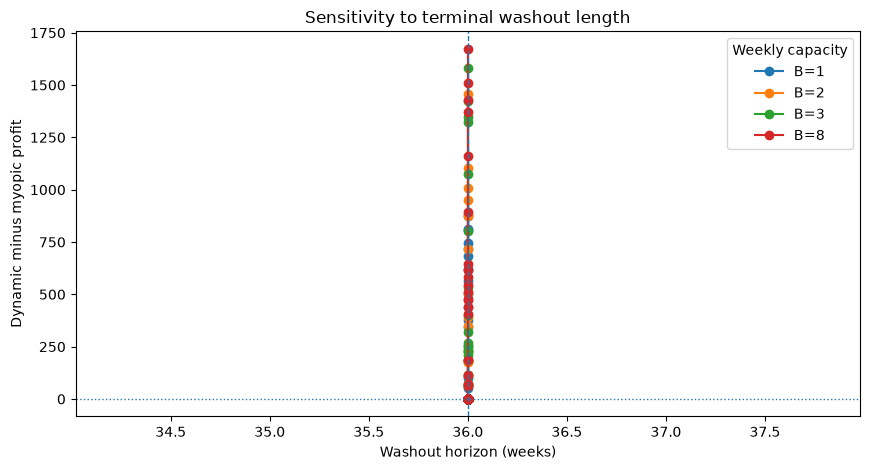

In [4]:
# Plot how VDO changes as delayed post-promotion effects are brought inside
# the evaluation window.
fig, ax = plt.subplots(figsize=(8.8, 4.8))

for capacity, group in washout_results.groupby(
    "capacity",
    observed=True,
):
    group = group.sort_values("washout_horizon")
    ax.plot(
        group["washout_horizon"],
        group["vdo"],
        marker="o",
        label=f"B={capacity}",
    )

ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.axvline(SELECTED_WASHOUT, linestyle="--", linewidth=1.0)
ax.set_xlabel("Washout horizon (weeks)")
ax.set_ylabel("Dynamic minus myopic profit")
ax.set_title("Sensitivity to terminal washout length")
ax.legend(title="Weekly capacity")
fig.tight_layout()

for suffix in ["png", "pdf"]:
    figure_path = FIGURE_DIR / f"vdo_washout_stability.{suffix}"
    fig.savefig(
        figure_path,
        dpi=300 if suffix == "png" else None,
        bbox_inches="tight",
    )

plt.show()

## 3. Identify discrete policy transitions

In [5]:
# Compare each policy signature with the preceding funding value within the same
# capacity. A change indicates a discrete boundary in the selected calendar or
# set of promoted product-week actions.
policy_regimes = policy_results.copy()

for signature_column in [
    "dynamic_schedule_signature",
    "myopic_schedule_signature",
    "dynamic_active_set",
    "myopic_active_set",
]:
    policy_regimes[f"{signature_column}_previous"] = (
        policy_regimes.groupby(
            "capacity",
            observed=True,
        )[signature_column].shift()
    )

policy_regimes["dynamic_schedule_change"] = (
    policy_regimes["dynamic_schedule_signature"]
    != policy_regimes["dynamic_schedule_signature_previous"]
)

policy_regimes["myopic_schedule_change"] = (
    policy_regimes["myopic_schedule_signature"]
    != policy_regimes["myopic_schedule_signature_previous"]
)

policy_regimes["dynamic_active_set_change"] = (
    policy_regimes["dynamic_active_set"]
    != policy_regimes["dynamic_active_set_previous"]
)

In [6]:
# Complete the boundary flags for the myopic active set.
policy_regimes["myopic_active_set_change"] = (
    policy_regimes["myopic_active_set"]
    != policy_regimes["myopic_active_set_previous"]
)

# The first funding value within each capacity has no preceding grid point and
# therefore cannot be classified as a policy transition.
first_rows = (
    policy_regimes.groupby(
        "capacity",
        observed=True,
    ).cumcount().eq(0)
)

for column in [
    "dynamic_schedule_change",
    "myopic_schedule_change",
    "dynamic_active_set_change",
    "myopic_active_set_change",
]:
    policy_regimes.loc[first_rows, column] = False

# Mark a grid point whenever at least one dynamic or myopic policy object changes.
policy_regimes["any_policy_boundary"] = (
    policy_regimes[
        [
            "dynamic_schedule_change",
            "myopic_schedule_change",
            "dynamic_active_set_change",
            "myopic_active_set_change",
        ]
    ].any(axis=1)
)

# Scale the best-versus-second-best gap by absolute dynamic profit to make the
# local degree of schedule separation comparable across grid points.
policy_regimes["relative_best_second_gap"] = (
    policy_regimes["best_second_gap"]
    / policy_regimes["dynamic_profit"].abs()
)

In [7]:
# Inspect the first policy boundaries and their associated VDO values.
display(
    policy_regimes.loc[
        policy_regimes["any_policy_boundary"],
        [
            "alpha",
            "capacity",
            "vdo",
            "vdo_percent",
            "best_second_gap",
            "dynamic_schedule_change",
            "myopic_schedule_change",
            "dynamic_active_set_change",
            "myopic_active_set_change",
        ],
    ].head(40)
)

,alpha,capacity,vdo,vdo_percent,best_second_gap,dynamic_schedule_change,myopic_schedule_change,dynamic_active_set_change,myopic_active_set_change
82,0.82,1,185.181351,0.063591,4.917012,False,True,False,True
84,0.84,1,69.224726,0.023759,0.117614,True,False,True,False
86,0.86,1,345.826870,0.118758,0.107279,False,True,False,True
87,0.87,1,100.235145,0.034385,0.102112,False,True,False,False
88,0.88,1,255.548599,0.087643,0.284257,True,True,True,True
89,0.89,1,805.841189,0.276604,0.191834,True,True,True,True
90,0.90,1,714.331330,0.244854,1.005281,True,False,True,False
91,0.91,1,618.188575,0.211585,0.807623,True,True,True,False
92,0.92,1,873.745907,0.298923,4.638069,True,True,True,True
95,0.95,1,684.556776,0.233101,0.532542,True,False,False,False


In [8]:
# Identify the largest VDO point within each capacity. These rows summarize
# where the model assigns the greatest value to forward-looking planning.
top_vdo_by_capacity = (
    policy_regimes.loc[
        policy_regimes.groupby(
            "capacity",
            observed=True,
        )["vdo"].idxmax(),
        [
            "capacity",
            "alpha",
            "vdo",
            "vdo_percent",
            "best_second_gap",
            "action_disagreements",
            "status_disagreements",
            "depth_disagreements",
            "timing_shift_products",
        ],
    ]
    .sort_values("capacity")
    .reset_index(drop=True)
)

display(top_vdo_by_capacity)

,capacity,alpha,vdo,vdo_percent,best_second_gap,action_disagreements,status_disagreements,depth_disagreements,timing_shift_products
0,1,0.92,873.745907,0.298923,4.638069,16,16,0,1
1,2,0.87,1454.993265,0.501453,0.102112,28,28,0,1
2,3,0.88,1579.793764,0.544248,0.018016,37,37,0,3
3,8,0.88,1672.946069,0.576520,0.017870,44,44,0,4


## Diagnostics / validation

### Additional policy diagnostics (not manuscript outputs)

In [9]:
# Report the policy comparison at the pre-specified main funding value.
scenario_rows = policy_results.copy()

if scenario_rows.empty:
    available_alphas = np.sort(
        policy_results["alpha"].unique()
    )

    raise RuntimeError(
        f"No reimbursement scenarios were found. "
        f"Available values are: {available_alphas}."
    )

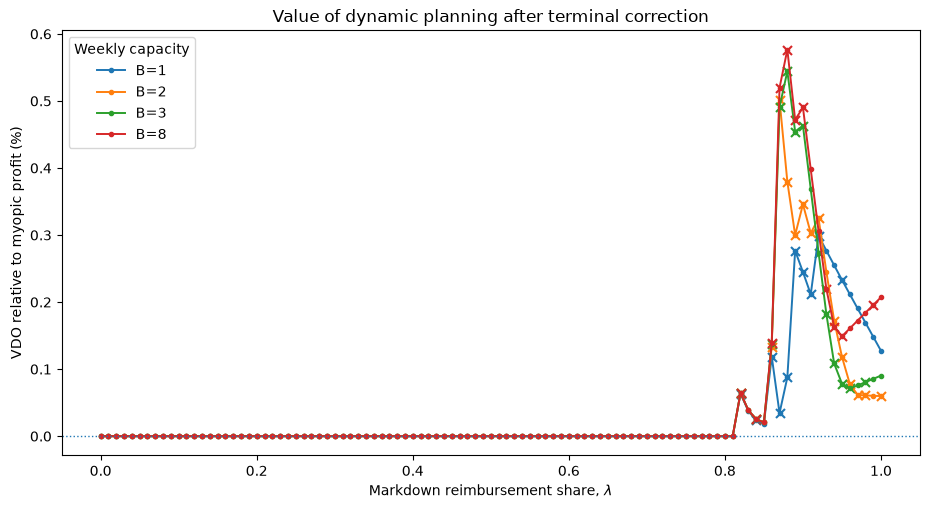

In [10]:
# Plot relative VDO across funding values and mark discrete policy boundaries.
fig, ax = plt.subplots(figsize=(9.4, 5.2))

for capacity, group in policy_regimes.groupby(
    "capacity",
    observed=True,
):
    group = group.sort_values("alpha")
    ax.plot(
        group["alpha"],
        group["vdo_percent"],
        marker="o",
        markersize=3,
        linewidth=1.4,
        label=f"B={capacity}",
    )

    boundary_group = group.loc[group["any_policy_boundary"]]
    ax.scatter(
        boundary_group["alpha"],
        boundary_group["vdo_percent"],
        marker="x",
        s=42,
    )

ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.set_xlabel(r"Markdown reimbursement share, $\lambda$")
ax.set_ylabel("VDO relative to myopic profit (%)")
ax.set_title("Value of dynamic planning after terminal correction")
ax.legend(title="Weekly capacity")
fig.tight_layout()

for suffix in ["png", "pdf"]:
    figure_path = FIGURE_DIR / f"vdo_percent_by_reimbursement_capacity.{suffix}"
    fig.savefig(
        figure_path,
        dpi=300 if suffix == "png" else None,
        bbox_inches="tight",
    )

plt.show()

Cross markers identify reimbursement-share values at which at least one calendar changes relative to the preceding grid point. They indicate discrete policy boundaries, not statistical significance.

## 5. Additive decomposition by product and week

In [11]:
# Use capacity two as the primary decomposition example.
MAIN_CAPACITY = 2

capacity_rows = policy_results.loc[
    policy_results["capacity"].eq(MAIN_CAPACITY)
].copy()

if capacity_rows.empty:
    raise RuntimeError(
        f"No policy results are available for capacity {MAIN_CAPACITY}."
    )

# Use the maximum-VDO scenario at this capacity for decomposition.
boundary_row = (
    capacity_rows.sort_values(
        "vdo",
        ascending=False,
    ).iloc[0]
)
BOUNDARY_ALPHA = float(boundary_row["alpha"])

DECOMPOSITION_ALPHAS = [round(BOUNDARY_ALPHA, 8)]

print("Decomposition alphas:", DECOMPOSITION_ALPHAS)

Decomposition alphas: [0.87]


In [12]:
# Restrict the stored product and week decompositions to the selected capacity
# and funding values.
selected_product_decomposition = product_decomposition.loc[
    product_decomposition["capacity"].eq(MAIN_CAPACITY)
    & product_decomposition["alpha"].round(8).isin(DECOMPOSITION_ALPHAS)
].copy()

selected_weekly_decomposition = weekly_decomposition.loc[
    weekly_decomposition["capacity"].eq(MAIN_CAPACITY)
    & weekly_decomposition["alpha"].round(8).isin(DECOMPOSITION_ALPHAS)
].copy()

if selected_product_decomposition.empty:
    raise RuntimeError(
        "No product decomposition rows match the selected capacity and alphas."
    )

if selected_weekly_decomposition.empty:
    raise RuntimeError(
        "No weekly decomposition rows match the selected capacity and alphas."
    )

# Sum contributions independently by product and week. Both should reproduce
# total VDO for each selected funding value.
product_accounting_check = (
    selected_product_decomposition.groupby(
        "alpha",
        observed=True,
    )["vdo_contribution"].sum()
)

weekly_accounting_check = (
    selected_weekly_decomposition.groupby(
        "alpha",
        observed=True,
    )["vdo_contribution"].sum()
)

In [13]:
# Display the two additive accounting identities side by side.
accounting_check = pd.concat(
    [
        product_accounting_check.rename("product_sum"),
        weekly_accounting_check.rename("weekly_sum"),
    ],
    axis=1,
)

if not np.allclose(
    accounting_check["product_sum"],
    accounting_check["weekly_sum"],
    atol=1e-6,
    rtol=1e-8,
):
    raise AssertionError(
        "Product and weekly VDO decompositions do not agree."
    )

display(accounting_check)

,product_sum,weekly_sum
alpha,,
0.87,1454.993265,1454.993265


In [14]:
# Rank products by their contribution to dynamic-minus-myopic profit.
product_rankings = selected_product_decomposition.sort_values(
    ["alpha", "vdo_contribution"],
    ascending=[True, False],
)

display(
    product_rankings[
        [
            "alpha",
            "upc",
            "dynamic_profit",
            "myopic_profit",
            "vdo_contribution",
        ]
    ]
)

# Aggregate weekly contributions by decision-week indicator to distinguish the
# planning horizon from the no-promotion washout period.
washout_attribution = (
    selected_weekly_decomposition.groupby(
        ["alpha", "decision_week"],
        observed=True,
    )["vdo_contribution"]
    .sum()
    .rename("vdo_contribution")
    .reset_index()
)

display(washout_attribution)

,alpha,upc,dynamic_profit,myopic_profit,vdo_contribution
1511,0.87,3800001611,34897.850431,33900.682889,997.167542
1506,0.87,1600066610,68442.577038,68124.623764,317.953274
1510,0.87,3800001520,31920.103601,31831.298418,88.805183
1507,0.87,3800000110,18311.329651,18285.973427,25.356224
1508,0.87,3800000120,24242.461098,24224.038998,18.422099
1509,0.87,3800000127,17403.063182,17395.774239,7.288943
1504,0.87,1600066510,46828.836047,46828.836047,0.000000
1505,0.87,1600066590,49564.149503,49564.149503,0.000000


,alpha,decision_week,vdo_contribution
0,0.87,False,614.937867
1,0.87,True,840.055398


C:\Users\janza\AppData\Local\Temp\ipykernel_12980\2895646883.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


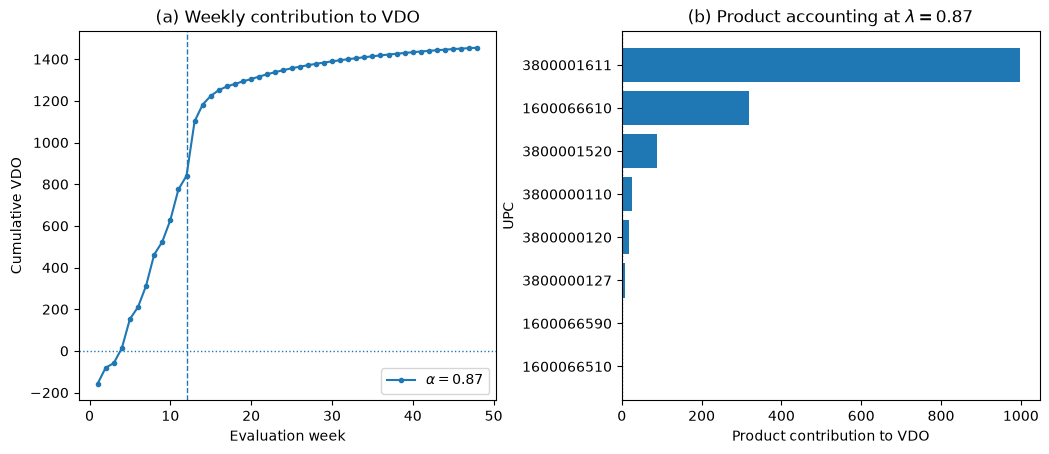

In [15]:
# Plot cumulative VDO over the evaluation horizon for the selected funding
# values. The vertical line marks the end of the decision horizon.
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8),
                        gridspec_kw={"width_ratios": [1.0, 1.0], "wspace": 0.30})

for alpha, group in selected_weekly_decomposition.groupby(
    "alpha",
    observed=True,
):
    group = group.sort_values("week")
    axes[0].plot(
        group["week"],
        group["cumulative_vdo"],
        marker="o",
        markersize=3,
        label=rf"$\alpha={alpha:.2f}$",
    )

axes[0].axvline(
    planning.decision_horizon,
    linestyle="--",
    linewidth=1.0,
)
axes[0].axhline(0.0, linestyle=":", linewidth=1.0)

axes[0].set_xlabel("Evaluation week")
axes[0].set_ylabel("Cumulative VDO")
axes[0].set_title("(a) Weekly contribution to VDO")
axes[0].legend()

# Plot the product-level accounting at the maximum-VDO scenario.
main_product = (
    selected_product_decomposition.loc[
        np.isclose(
            selected_product_decomposition["alpha"],
            BOUNDARY_ALPHA,
        )
    ]
    .sort_values("vdo_contribution")
)

if main_product.empty:
    raise RuntimeError(
        "No product decomposition is available at the maximum-VDO scenario."
    )

axes[1].barh(
    main_product["upc"].astype(str),
    main_product["vdo_contribution"],
)
axes[1].axvline(0.0, linestyle=":", linewidth=1.0)

axes[1].set_xlabel("Product contribution to VDO")
axes[1].set_ylabel("UPC")
axes[1].set_title(
    rf"(b) Product accounting at $\lambda={BOUNDARY_ALPHA:.2f}$"
)

fig.tight_layout()

DECOMPOSITION_FIGURE_PNG = (
    FIGURE_DIR / "figure_03_vdo_decomposition.png"
)
DECOMPOSITION_FIGURE_PDF = (
    FIGURE_DIR / "figure_03_vdo_decomposition.pdf"
)

# Export both raster and vector versions for reporting.
fig.savefig(
    DECOMPOSITION_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    DECOMPOSITION_FIGURE_PDF,
    bbox_inches="tight",
)

In [16]:
# Display the completed decomposition figure.
plt.show()

### VDO accounting diagnostics (not manuscript outputs)

The product and week decompositions are additive accounting identities:
$$
\operatorname{VDO}
=
\sum_i\left[V_i(\pi^D)-V_i(\pi^M)\right]
=
\sum_t\left[V_t(\pi^D)-V_t(\pi^M)\right].
$$
Because products interact through the weekly capacity constraint, these contributions should not be interpreted as independent causal treatment effects.

## 6. Largest local changes across adjacent reimbursement shares

In [17]:
# Compare schedules at adjacent funding values and record the products and
# product-week actions responsible for each local policy switch.
policy_switches = build_policy_switch_table(
    policy_results=policy_results,
    schedules=schedules,
)

if policy_switches.empty:
    print("No adjacent-grid policy switches were detected.")

In [18]:
# Inspect the largest or earliest local schedule changes returned by the helper.
display(policy_switches.head(20))

,capacity,alpha_previous,alpha_current,vdo_previous,vdo_current,vdo_change,dynamic_changed_products,dynamic_changed_cells,myopic_changed_products,myopic_changed_cells
0,8,0.86,0.87,404.817597,1507.365384,1102.547787,,0,1600066610|3800001611,8
1,2,0.86,0.87,389.433949,1454.993265,1065.559316,,0,1600066610|3800000110|3800000127|3800001520|38...,32
2,3,0.86,0.87,400.811243,1424.742532,1023.931289,,0,1600066610|3800001611,8
3,1,0.88,0.89,255.548599,805.841189,550.292591,3800000110|3800000127,5,1600066610|3800001611,8
4,2,0.87,0.88,1454.993265,1103.878815,-351.114450,3800000110|3800000120|3800000127|3800001520,13,3800000127|3800001611,16
5,8,0.85,0.86,59.919600,404.817597,344.897996,,0,3800000110|3800001520,8
6,3,0.85,0.86,59.919600,400.811243,340.891642,,0,3800000110|3800001520,8
7,2,0.85,0.86,59.919600,389.433949,329.514348,,0,3800000110|3800001520,8
8,8,0.88,0.89,1672.946069,1372.614740,-300.331330,3800001520,2,,0
9,1,0.85,0.86,54.720165,345.826870,291.106705,,0,3800001520,4


## 7. Export policy-result diagnostics

In [19]:
# Export human-readable diagnostics used in the manuscript and appendices.
output_tables = {
    "policy_washout_results.csv": washout_results,
    "policy_washout_stability.csv": washout_stability,
    "policy_reimbursement_curve.csv": scenario_rows,
    "three_policy_sequential_decomposition.csv": policy_results[[
        "capacity", "reimbursement_share", "myopic_profit",
        "naive_dynamic_profit", "dynamic_profit",
        "forward_planning_naive_increment",
        "displacement_aware_increment", "vdo",
    ]],
    "policy_regimes.csv": policy_regimes,
    "top_vdo_by_capacity.csv": top_vdo_by_capacity,
    "product_vdo_decomposition.csv": selected_product_decomposition,
    "weekly_vdo_decomposition.csv": selected_weekly_decomposition,
    "policy_boundary_switches.csv": policy_switches,
}

for filename, frame in output_tables.items():
    frame.to_csv(TABLE_DIR / filename, index=False)

RESULTS_ARTIFACT_PATH = POLICY_ARTIFACT_DIR / "policy_results.pkl"
results_artifact = {
    "washout_results": washout_results,
    "washout_stability": washout_stability,
    "reimbursement_curve": scenario_rows,
    "policy_regimes": policy_regimes,
    "top_vdo_by_capacity": top_vdo_by_capacity,
    "decomposition_alphas": DECOMPOSITION_ALPHAS,
    "product_decomposition": selected_product_decomposition,
    "weekly_decomposition": selected_weekly_decomposition,
    "policy_switches": policy_switches,
    "economic_profile_mode": ECONOMIC_PROFILE_MODE,
    "selected_washout": SELECTED_WASHOUT,
}

save_pickle(results_artifact, RESULTS_ARTIFACT_PATH)
print("Saved:", RESULTS_ARTIFACT_PATH)

Saved: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\policy\empirical_bayes\policy_results.pkl


## 8. Final-output handoff

Notebook 08 validates the 0.01 candidate grid, checks the additive value identity, and writes the final four-panel decomposition, the capacity-two switching rug, and the accompanying transition tables. Same-mask pruning is exact for the selected optimum at every reported reimbursement share; the retained-candidate gap diagnostic is not evidence about a literal second-best feasible calendar.

In [20]:
from IPython.display import Image, display
import subprocess

report_script = PROJECT_ROOT / 'scripts' / 'build_three_policy_figures.py'
task8_grid = TABLE_DIR / 'task8_three_policy_reporting_grid.csv'
if task8_grid.exists():
    subprocess.run([sys.executable, str(report_script)], cwd=PROJECT_ROOT, check=True)
    display(Image(filename=str(FIGURE_DIR / 'three_policy_components_by_capacity.png')))
    print('Calendar switches by policy (B=2)')
    display(Image(filename=str(FIGURE_DIR / 'three_policy_switching_rug_B2.png')))
    display(pd.read_csv(TABLE_DIR / 'three_policy_transition_table_B2.csv').head(20))
    display(pd.read_csv(TABLE_DIR / 'three_policy_transition_summary.csv'))
    display(pd.read_csv(TABLE_DIR / 'candidate_pruning_exactness.csv'))
    display(pd.read_csv(TABLE_DIR / 'three_policy_calendar_audit.csv'))
else:
    print('Final percentage figures and transition tables are generated by Notebook 08 after Task-8 normalization.')

Final percentage figures and transition tables are generated by Notebook 08 after Task-8 normalization.
